# 1. Setup
Install and set up dataset and repo, test if correct

In [ ]:
import torch
print("CUDA:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA: True
Device: Tesla T4


In [ ]:
!pip install -q braindecode
!pip install -q moabb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 497.9/497.9 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 115.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
moviepy 1.0.3 require

In [ ]:
%cd /content
!rm -rf CAMP
!git clone https://github.com/LukasThrane/CAMP.git
%cd CAMP

/content
Cloning into 'CAMP'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 44 (delta 14), reused 36 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 13.76 MiB | 20.93 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/CAMP


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/CAMP-results

Mounted at /content/drive


In [ ]:
import glob
import os

# Search for all result files
for pattern in [
    '/content/drive/MyDrive/CAMP-results/**/*.csv',
    '/content/drive/MyDrive/CAMP-results/**/*.json',
    '/content/drive/MyDrive/CAMP-results/**/*.pt',
    '/content/drive/MyDrive/CAMP-results/**/*.png',
]:
    files = glob.glob(pattern, recursive=True)
    for f in sorted(files):
        size = os.path.getsize(f) / 1024
        print(f"{size:8.1f} KB  {f}")

     1.1 KB  /content/drive/MyDrive/CAMP-results/grid/grid.csv
     1.2 KB  /content/drive/MyDrive/CAMP-results/grid_v2/grid.csv
     0.2 KB  /content/drive/MyDrive/CAMP-results/smoke_pA/grid.csv
     0.1 KB  /content/drive/MyDrive/CAMP-results/smoketest/grid.csv
     4.8 KB  /content/drive/MyDrive/CAMP-results/grid/grid.json
    94.1 KB  /content/drive/MyDrive/CAMP-results/grid_v2/grid.json
     2.5 KB  /content/drive/MyDrive/CAMP-results/smoke_pA/grid.json
     9.3 KB  /content/drive/MyDrive/CAMP-results/smoketest/grid.json
  2560.7 KB  /content/drive/MyDrive/CAMP-results/grid/checkpoints/A_full_decoder.pt
  2560.6 KB  /content/drive/MyDrive/CAMP-results/grid/checkpoints/B_camp_b0.1.pt
  2560.6 KB  /content/drive/MyDrive/CAMP-results/grid/checkpoints/B_camp_b0.2.pt
  2560.6 KB  /content/drive/MyDrive/CAMP-results/grid/checkpoints/B_camp_b0.5.pt
  2560.6 KB  /content/drive/MyDrive/CAMP-results/grid/checkpoints/B_camp_b0.9.pt
  2560.6 KB  /content/drive/MyDrive/CAMP-results/grid/checkp

In [ ]:
import json
import pandas as pd

with open('/content/drive/MyDrive/CAMP-results/grid_v2/grid.json') as f:
    results = json.load(f)

rows = []
for r in results:
    if 'error' not in r:
        rows.append({
            'strategy': r['strategy'],
            'B': r['bandwidth_frac'],
            'r_mean': round(r['best_r_mean'], 3),
        })

df = pd.DataFrame(rows).sort_values(['strategy', 'B'])
print(df.to_string(index=False))

         strategy   B  r_mean
        camp_beta 0.1   0.049
        camp_beta 0.3   0.127
        camp_beta 0.9   0.408
       camp_gamma 0.1   0.300
       camp_gamma 0.3   0.371
       camp_gamma 0.9   0.651
 camp_hybrid_beta 0.1   0.084
 camp_hybrid_beta 0.3   0.333
 camp_hybrid_beta 0.9   0.600
camp_hybrid_gamma 0.1   0.315
camp_hybrid_gamma 0.3   0.516
camp_hybrid_gamma 0.9   0.647
    camp_saliency 0.1   0.078
    camp_saliency 0.3   0.412
    camp_saliency 0.9   0.592
             full 1.0   0.681
      round_robin 0.1   0.037
      round_robin 0.3   0.168
      round_robin 0.9   0.530


# 2. Run simulation

In [ ]:
# Full test for paper
!python run_experiment.py \
    --paradigm B \
    --strategies full round_robin camp_beta camp_gamma camp_saliency camp_hybrid_beta camp_hybrid_gamma \
    --bandwidths 1.0 0.9 0.3 0.1 \
    --epochs 15 \
    --device cuda \
    --saliency-path /content/drive/MyDrive/CAMP-results/saliency/saliency_subject_1.npz \
    --out-dir /content/drive/MyDrive/CAMP-results/grid_v2 \
    --resume

Paradigm:   B
Strategies: ['full', 'round_robin', 'camp_beta', 'camp_gamma', 'camp_saliency', 'camp_hybrid_beta', 'camp_hybrid_gamma']
Bandwidths: [1.0, 0.9, 0.3, 0.1]
Device: cuda, batch=128, epochs=15
[load] subject 1 via braindecode (official split)…
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
/usr/local/lib/python3.12/dist-packages/moabb/datasets/download.py:97: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BCICOMPETITIONIVDATASET4_PATH"
  set_config(key, get_config("MNE_DATA"))
SHA256 hash of downloaded file: 04c237ab33f25eb11c93d4cea69693823693d16ef145d4a034a77ddae6238ebb
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
Creating RawArray with float64 data, n_channels=67, n_times=400000
  

In [ ]:
# Saliency Report
!ls -la /content/drive/MyDrive/CAMP-results/grid/checkpoints/

!python saliency.py \
    --checkpoint /content/drive/MyDrive/CAMP-results/grid/checkpoints/B_full_b1.0.pt \
    --out-dir /content/drive/MyDrive/CAMP-results/saliency \
    --device cuda \
    --n-windows 200

total 28171
-rw------- 1 root root 2622169 Apr 26 13:45 A_full_decoder.pt
-rw------- 1 root root 2622046 Apr 26 13:36 B_camp_b0.1.pt
-rw------- 1 root root 2622046 Apr 26 13:25 B_camp_b0.2.pt
-rw------- 1 root root 2622046 Apr 26 13:16 B_camp_b0.5.pt
-rw------- 1 root root 2622046 Apr 26 13:06 B_camp_b0.9.pt
-rw------- 1 root root 2622046 Apr 26 16:49 B_full_b1.0.pt
-rw------- 1 root root 2622333 Apr 26 12:54 B_round_robin_b0.1.pt
-rw------- 1 root root 2622333 Apr 26 12:45 B_round_robin_b0.2.pt
-rw------- 1 root root 2622333 Apr 26 12:36 B_round_robin_b0.5.pt
-rw------- 1 root root 2622333 Apr 26 16:57 B_round_robin_b0.9.pt
-rw------- 1 root root 2621964 Apr 26 11:05 full_b0.5.pt
Loading checkpoint: /content/drive/MyDrive/CAMP-results/grid/checkpoints/B_full_b1.0.pt
  trained to epoch 15, r_mean = 0.6968300067217074
Loading data + preprocessing (full-resolution, no chip)…
[cache] loading cache/raw_split_subject_1.pkl
^C


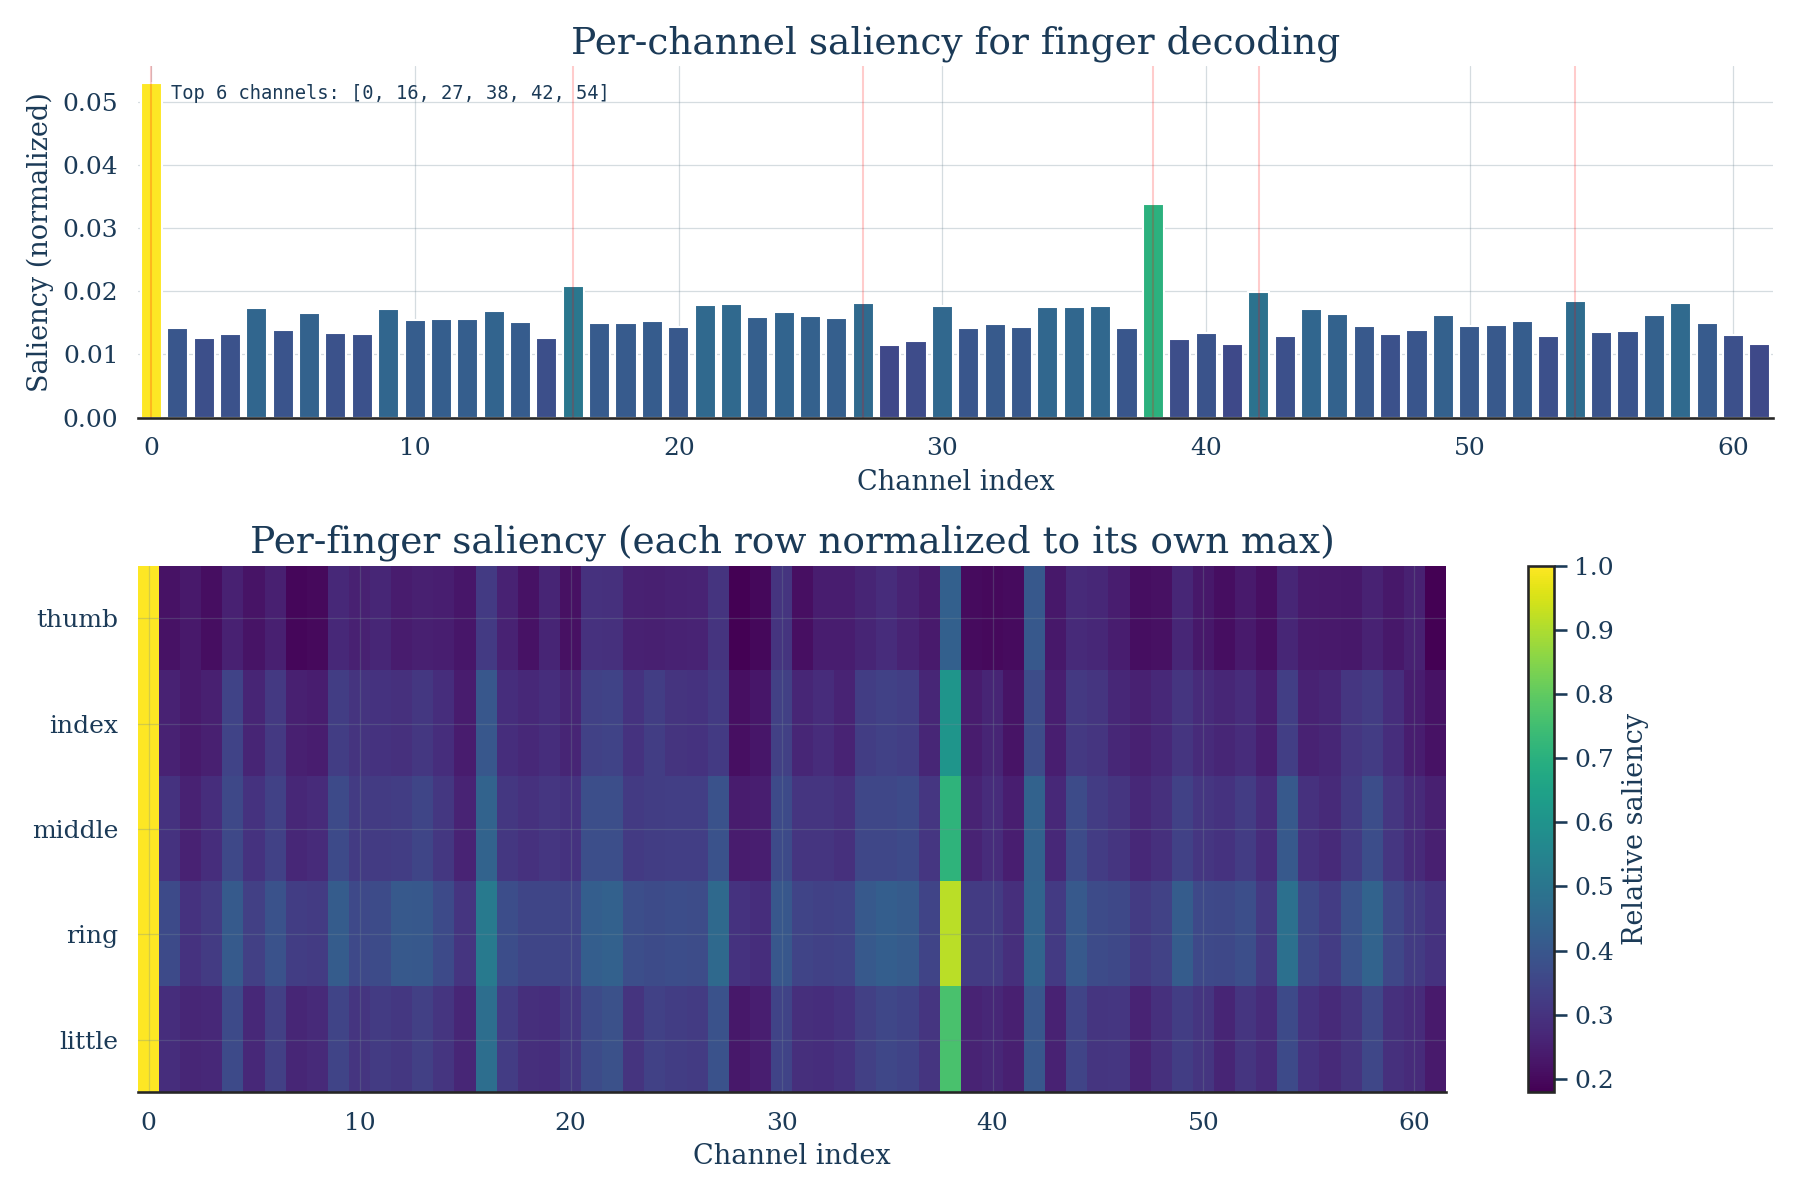

In [ ]:
from IPython.display import Image
Image('/content/drive/MyDrive/CAMP-results/saliency/saliency_subject_1.png')

# 3. Visualize results

In [ ]:
# ── SETUP ────────────────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.linewidth': 1.2,
    'figure.dpi': 150,
})

RESULTS_V2   = Path('/content/drive/MyDrive/CAMP-results/grid_v2')
SALIENCY_DIR = Path('/content/drive/MyDrive/CAMP-results/saliency')
FIG_DIR      = Path('/content/drive/MyDrive/CAMP-results/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load results
with open(RESULTS_V2 / 'grid.json') as f:
    raw = json.load(f)

rows = []
for r in raw:
    if 'error' not in r:
        rows.append({
            'strategy':  r['strategy'],
            'B':         r['bandwidth_frac'],
            'r_mean':    r['best_r_mean'],
            'r_thumb':   r['best_r_per_finger'][0],
            'r_index':   r['best_r_per_finger'][1],
            'r_middle':  r['best_r_per_finger'][2],
            'r_ring':    r['best_r_per_finger'][3],
            'r_little':  r['best_r_per_finger'][4],
        })
df = pd.DataFrame(rows).sort_values(['strategy', 'B'])

# Load saliency
sal = np.load(SALIENCY_DIR / 'saliency_subject_1.npz')
saliency     = sal['saliency']        # (62,)
per_finger   = sal['per_finger']      # (5, 62)

# Load raw ECoG
from data_loader import load_subject_split
split = load_subject_split(1)
ecog_train    = split['ecog_train']     # (62, 400000)
fingers_train = split['fingers_train']  # (5,  400000)
sfreq         = split['sfreq']

STRATEGY_STYLE = {
    'full':               dict(color='black',      ls='--',  lw=2.5, marker='s', label='Full resolution'),
    'round_robin':        dict(color='#e74c3c',    ls='-',   lw=2,   marker='o', label='Round robin'),
    'camp_beta':          dict(color='#3498db',    ls='-',   lw=2,   marker='^', label='CAMP-β (beta desync)'),
    'camp_gamma':         dict(color='#2ecc71',    ls='-',   lw=2,   marker='v', label='CAMP-γ (high-gamma)'),
    'camp_saliency':      dict(color='#f39c12',    ls='-',   lw=2,   marker='D', label='CAMP-saliency (static)'),
    'camp_hybrid_beta':   dict(color='#9b59b6',    ls='-',   lw=2,   marker='*', label='CAMP-hybrid-β'),
    'camp_hybrid_gamma':  dict(color='#1abc9c',    ls='-',   lw=2,   marker='P', label='CAMP-hybrid-γ'),
}
FINGER_NAMES = ['Thumb', 'Index', 'Middle', 'Ring', 'Little']
FINGER_COLORS = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']

print("Setup complete.")

[cache] loading cache/raw_split_subject_1.pkl
Setup complete.


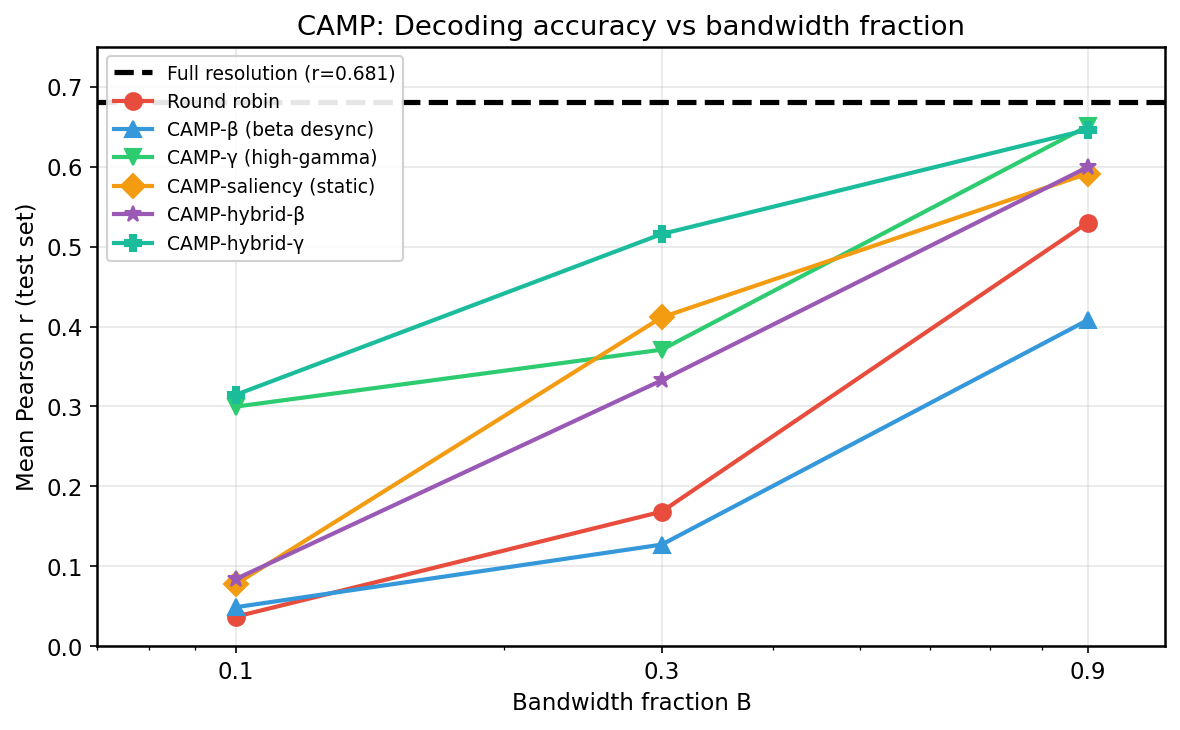

Saved fig1_main_curve


In [ ]:
# ── FIGURE 1: Main result — Pearson r vs bandwidth ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

full_r = df[df.strategy == 'full']['r_mean'].values[0]
Bs = sorted(df[df.strategy != 'full']['B'].unique())
ax.axhline(full_r, color='black', ls='--', lw=2.5, label=f'Full resolution (r={full_r:.3f})')

for strat, style in STRATEGY_STYLE.items():
    if strat == 'full':
        continue
    sub = df[df.strategy == strat].sort_values('B')
    if sub.empty:
        continue
    ax.plot(sub['B'], sub['r_mean'],
            color=style['color'], ls=style['ls'], lw=style['lw'],
            marker=style['marker'], markersize=8, label=style['label'])

ax.set_xlabel('Bandwidth fraction B')
ax.set_ylabel('Mean Pearson r (test set)')
ax.set_title('CAMP: Decoding accuracy vs bandwidth fraction')
ax.set_xscale('log')
ax.set_xticks([0.1, 0.3, 0.9])
ax.set_xticklabels(['0.1', '0.3', '0.9'])
ax.set_xlim(0.07, 1.1)
ax.set_ylim(0, 0.75)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1_main_curve.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig1_main_curve.png', bbox_inches='tight')
plt.show()
print("Saved fig1_main_curve")

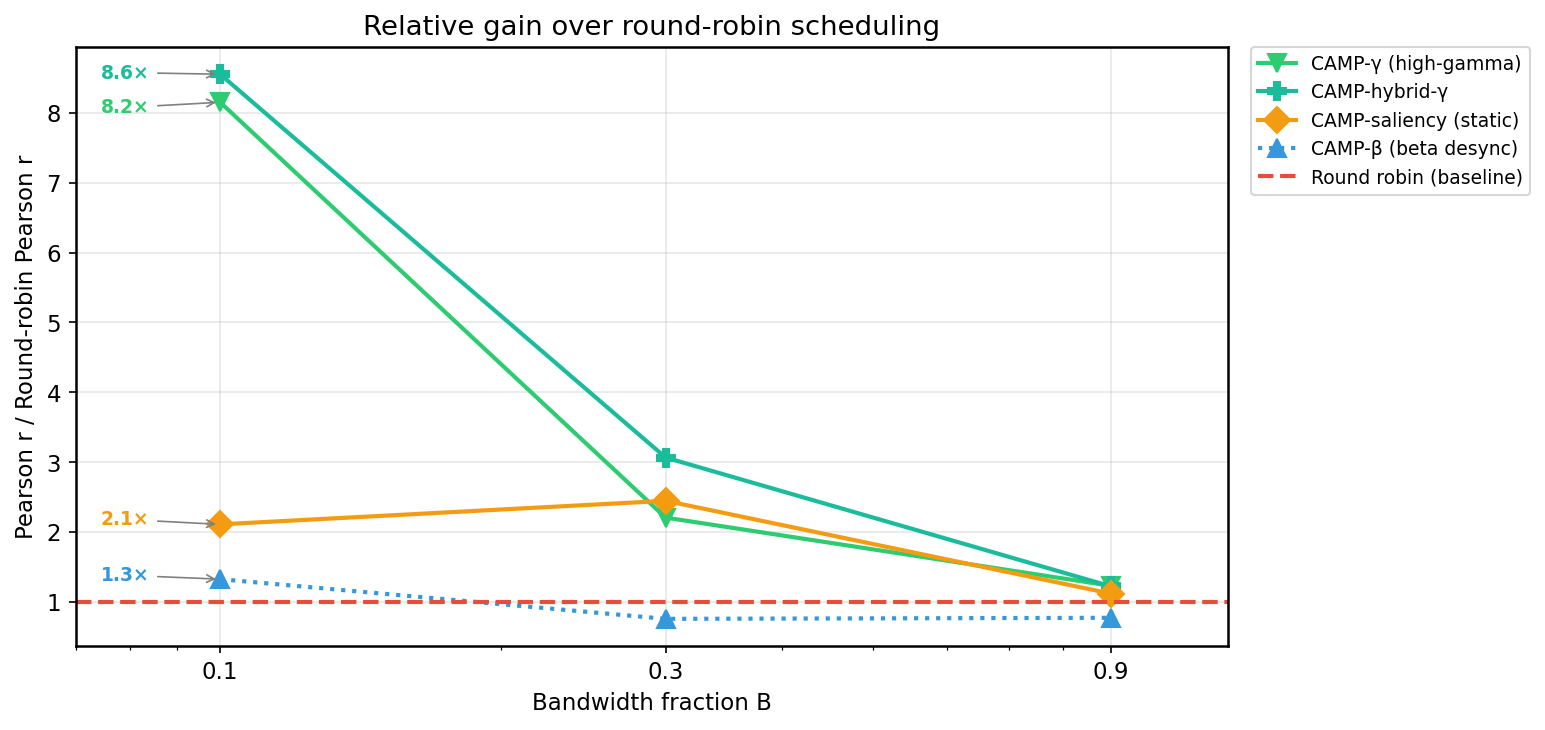

Saved fig2_relative_gain


In [ ]:
# ── FIGURE 2: Relative gain over round robin ──────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

rr = df[df.strategy == 'round_robin'].set_index('B')['r_mean']
strategies_to_plot = ['camp_gamma', 'camp_hybrid_gamma', 'camp_saliency', 'camp_beta']

gains = {}
for strat in strategies_to_plot:
    sub = df[df.strategy == strat].sort_values('B')
    gain = sub.set_index('B')['r_mean'] / rr
    gains[strat] = gain
    style = STRATEGY_STYLE[strat]
    ls = ':' if strat == 'camp_beta' else style['ls']
    ax.plot(gain.index, gain.values,
            color=style['color'], ls=ls, lw=style['lw'],
            marker=style['marker'], markersize=9, label=style['label'])

ax.axhline(1.0, color='#e74c3c', ls='--', lw=2, label='Round robin (baseline)')

ax.set_xlabel('Bandwidth fraction B')
ax.set_ylabel('Pearson r / Round-robin Pearson r')
ax.set_title('Relative gain over round-robin scheduling')
ax.set_xscale('log')
ax.set_xticks([0.1, 0.3, 0.9])
ax.set_xticklabels(['0.1', '0.3', '0.9'])
ax.set_xlim(0.07, 1.2)
ax.grid(True, alpha=0.3)

# Place legend outside to the right
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

# Annotate B=0.1 values — place text to the LEFT of the data points
# so they sit in the empty space before B=0.1 on the log axis
annotation_config = {
    'camp_hybrid_gamma': dict(xytext=(0.084, 8.5)),
    'camp_gamma':        dict(xytext=(0.084, 8.0)),
    'camp_saliency':     dict(xytext=(0.084, 2.1)),
    'camp_beta':         dict(xytext=(0.084, 1.3)),
}
for strat, gain in gains.items():
    if 0.1 in gain.index:
        val = gain.loc[0.1]
        cfg = annotation_config[strat]
        ax.annotate(
            f'{val:.1f}×',
            xy=(0.1, val),
            xytext=cfg['xytext'],
            fontsize=9,
            color=STRATEGY_STYLE[strat]['color'],
            fontweight='bold',
            ha='right',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
        )

fig.tight_layout()
fig.subplots_adjust(right=0.75)
fig.savefig(FIG_DIR / 'fig2_relative_gain.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig2_relative_gain.png', bbox_inches='tight')
plt.show()
print("Saved fig2_relative_gain")

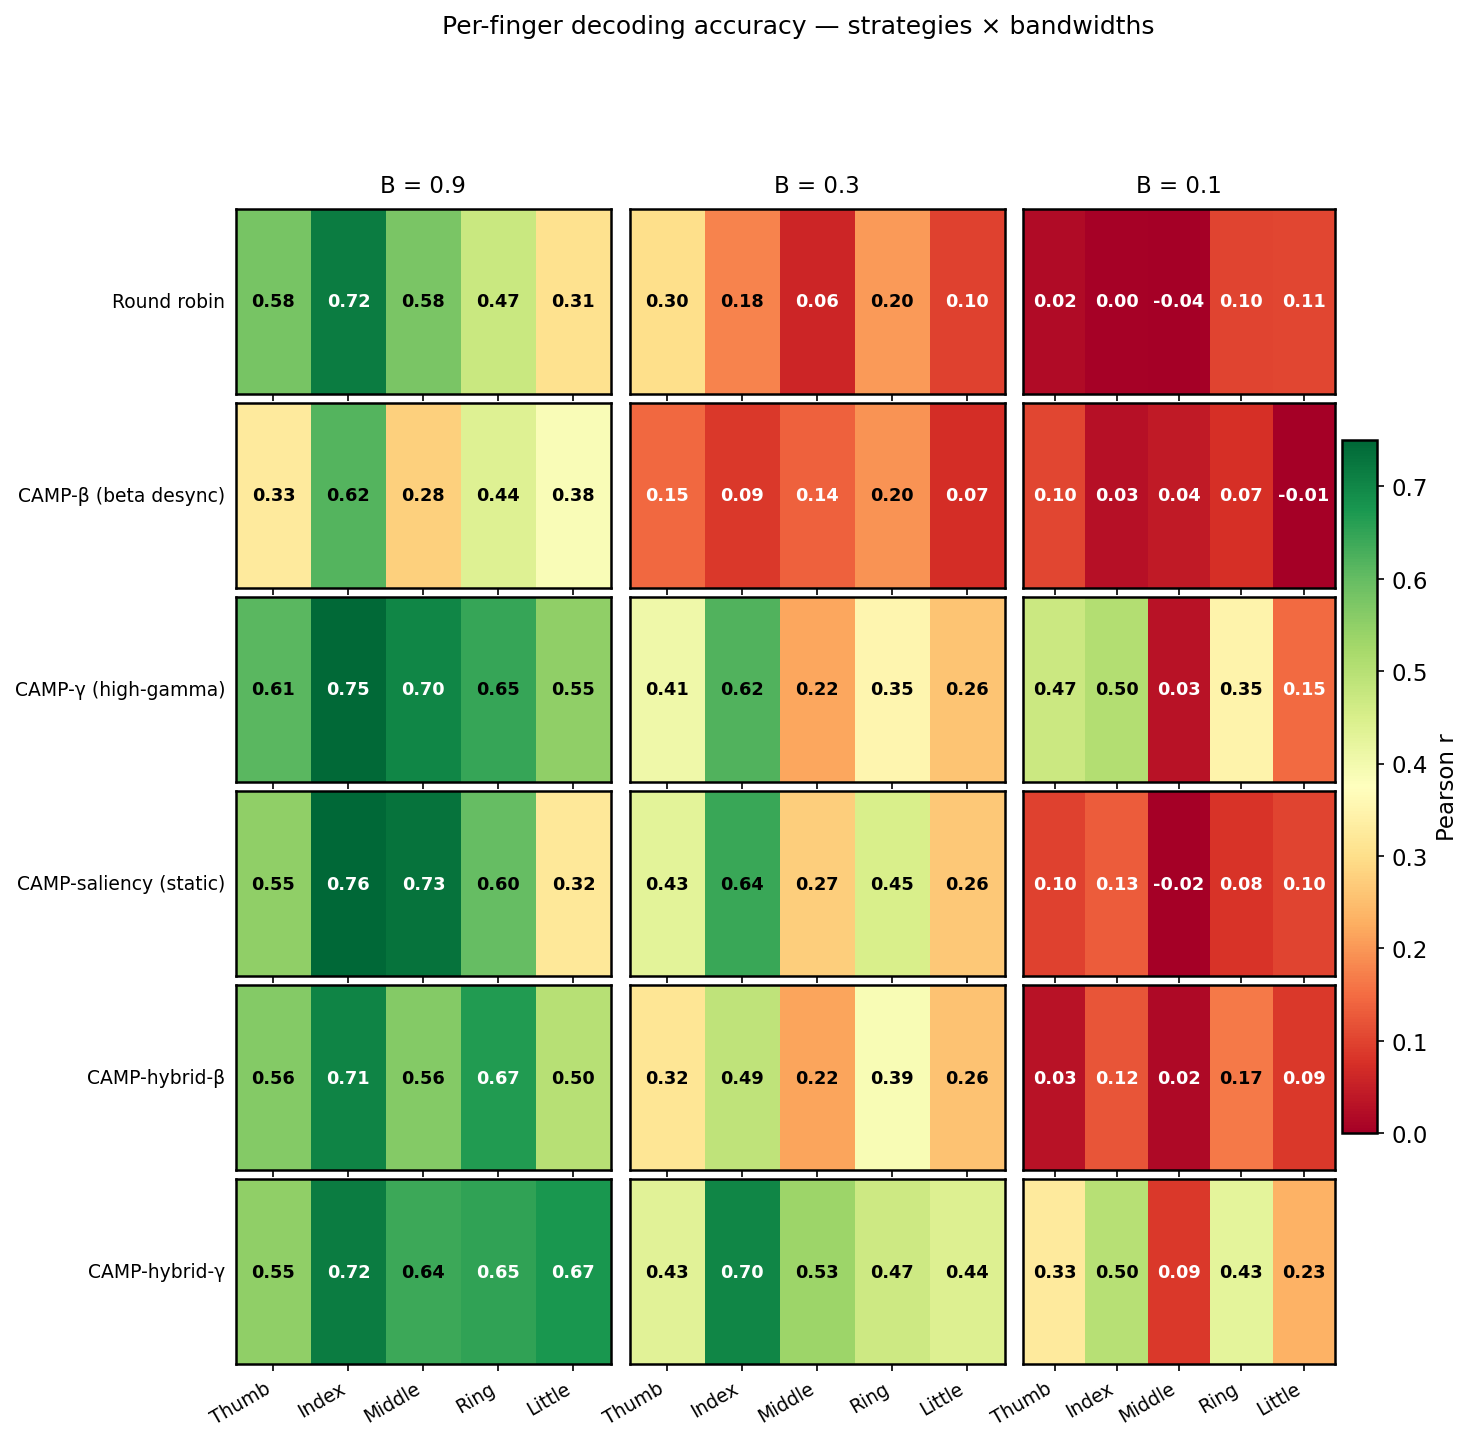

Saved fig3_per_finger_heatmap


In [ ]:
# ── FIGURE 3: Per-finger breakdown heatmap ────────────────────────────────────
strategies_ordered = [
    'round_robin', 'camp_beta', 'camp_gamma',
    'camp_saliency', 'camp_hybrid_beta', 'camp_hybrid_gamma'
]
bandwidths = [0.9, 0.3, 0.1]
finger_cols = ['r_thumb', 'r_index', 'r_middle', 'r_ring', 'r_little']

# One row per strategy, one column per bandwidth
fig, axes = plt.subplots(
    len(strategies_ordered), len(bandwidths),
    figsize=(10, 10),
    sharex=True
)
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for row_i, strat in enumerate(strategies_ordered):
    for col_i, B in enumerate(bandwidths):
        ax = axes[row_i, col_i]
        row = df[(df.strategy == strat) & (df.B == B)]
        if row.empty:
            vals = [np.nan] * 5
        else:
            vals = row[finger_cols].values[0].tolist()
        matrix = np.array(vals).reshape(1, 5)

        im = ax.imshow(matrix, vmin=0, vmax=0.75,
                       cmap='RdYlGn', aspect='auto')
        ax.set_yticks([])

        # Value annotations
        for j, val in enumerate(vals):
            if not np.isnan(val):
                color = 'black' if 0.15 < val < 0.65 else 'white'
                ax.text(j, 0, f'{val:.2f}', ha='center', va='center',
                        fontsize=8.5, color=color, fontweight='bold')

        # Left label — strategy name
        if col_i == 0:
            ax.set_ylabel(STRATEGY_STYLE[strat]['label'],
                          fontsize=9, rotation=0,
                          ha='right', va='center', labelpad=5)

        # Top label — bandwidth
        if row_i == 0:
            ax.set_title(f'B = {B}', fontsize=11, pad=8)

        # Bottom labels — finger names
        if row_i == len(strategies_ordered) - 1:
            ax.set_xticks(range(5))
            ax.set_xticklabels(FINGER_NAMES, rotation=30,
                               ha='right', fontsize=9)
        else:
            ax.set_xticks([])

# Colorbar
cbar = fig.colorbar(im, ax=axes[:, -1], label='Pearson r',
                    shrink=0.6, pad=0.02)

fig.suptitle('Per-finger decoding accuracy — strategies × bandwidths',
             fontsize=12, y=1.01)

fig.savefig(FIG_DIR / 'fig3_per_finger_heatmap.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig3_per_finger_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved fig3_per_finger_heatmap")

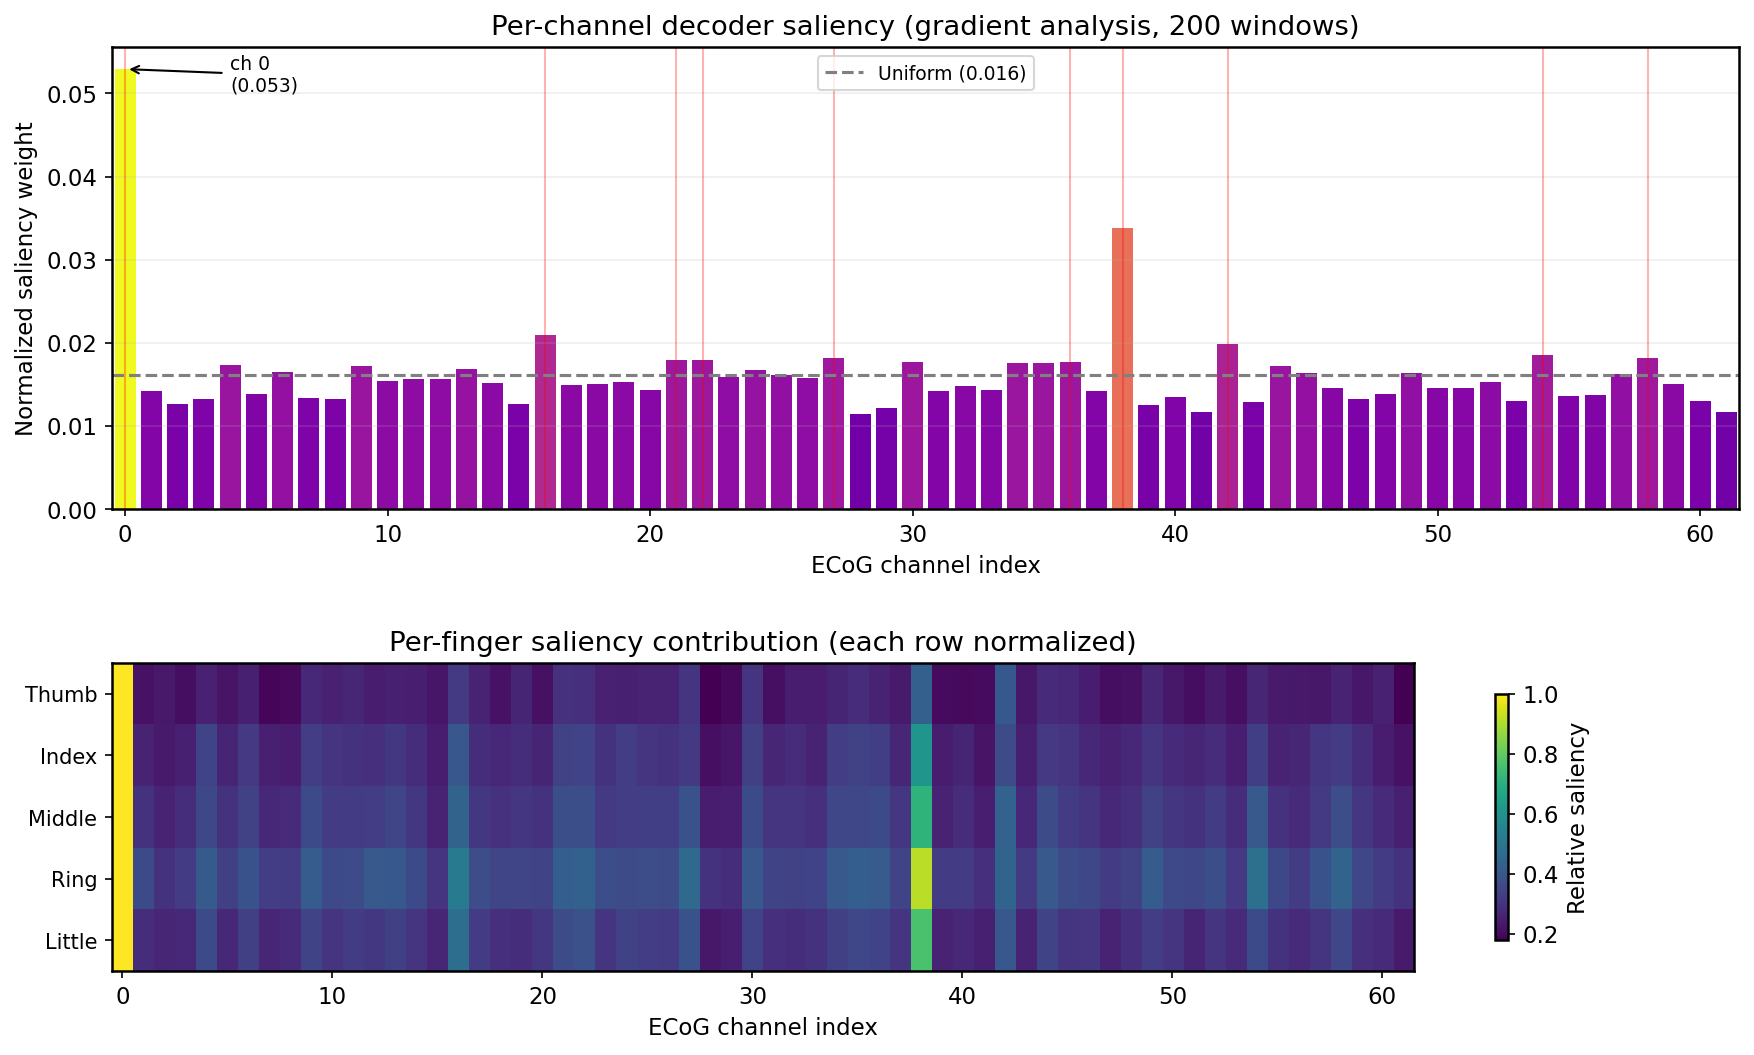

Saved fig4_saliency


In [ ]:
# ── FIGURE 4: Saliency — channel importance bar + per-finger heatmap ─────────
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[1.5, 1], hspace=0.4)

# Top: bar chart
ax1 = fig.add_subplot(gs[0])
colors = plt.cm.plasma(saliency / saliency.max())
ax1.bar(range(62), saliency, color=colors, width=0.8)
top10 = np.argsort(-saliency)[:10]
for i in top10:
    ax1.axvline(i, color='red', alpha=0.3, lw=1)
uniform = 1.0 / 62
ax1.axhline(uniform, color='gray', ls='--', lw=1.5, label=f'Uniform ({uniform:.3f})')
ax1.set_xlabel('ECoG channel index')
ax1.set_ylabel('Normalized saliency weight')
ax1.set_title('Per-channel decoder saliency (gradient analysis, 200 windows)')
ax1.set_xlim(-0.5, 61.5)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2, axis='y')
# Annotate top channel
top1 = np.argmax(saliency)
ax1.annotate(f'ch {top1}\n({saliency[top1]:.3f})',
             xy=(top1, saliency[top1]),
             xytext=(top1 + 4, saliency[top1] * 0.95),
             fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

# Bottom: per-finger heatmap
ax2 = fig.add_subplot(gs[1])
pf_norm = per_finger / (per_finger.max(axis=1, keepdims=True) + 1e-12)
im = ax2.imshow(pf_norm, aspect='auto', cmap='viridis', interpolation='nearest')
ax2.set_yticks(range(5))
ax2.set_yticklabels(FINGER_NAMES, fontsize=10)
ax2.set_xlabel('ECoG channel index')
ax2.set_title('Per-finger saliency contribution (each row normalized)')
plt.colorbar(im, ax=ax2, label='Relative saliency', shrink=0.8)

fig.savefig(FIG_DIR / 'fig4_saliency.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig4_saliency.png', bbox_inches='tight')
plt.show()
print("Saved fig4_saliency")

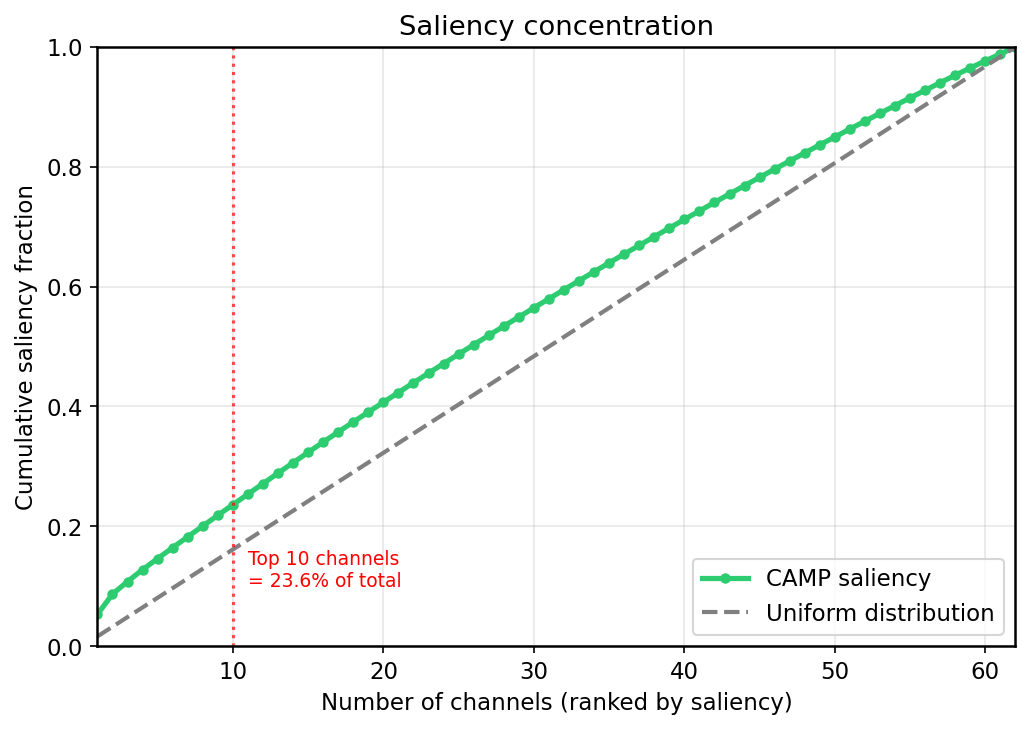

Saved fig5_saliency_concentration


In [ ]:
# ── FIGURE 5: Saliency concentration curve (Lorenz-style) ────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

sorted_sal = np.sort(saliency)[::-1]
cumulative = np.cumsum(sorted_sal)
x = np.arange(1, 63)

ax.plot(x, cumulative, color='#2ecc71', lw=2.5, marker='o',
        markersize=4, label='CAMP saliency')
ax.plot(x, x / 62, color='gray', ls='--', lw=2, label='Uniform distribution')
ax.axvline(10, color='red', ls=':', lw=1.5, alpha=0.7)
ax.text(11, 0.1, f'Top 10 channels\n= {cumulative[9]:.1%} of total', fontsize=9, color='red')

ax.set_xlabel('Number of channels (ranked by saliency)')
ax.set_ylabel('Cumulative saliency fraction')
ax.set_title('Saliency concentration')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 62)
ax.set_ylim(0, 1)

fig.tight_layout()
fig.savefig(FIG_DIR / 'fig5_saliency_concentration.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig5_saliency_concentration.png', bbox_inches='tight')
plt.show()
print("Saved fig5_saliency_concentration")

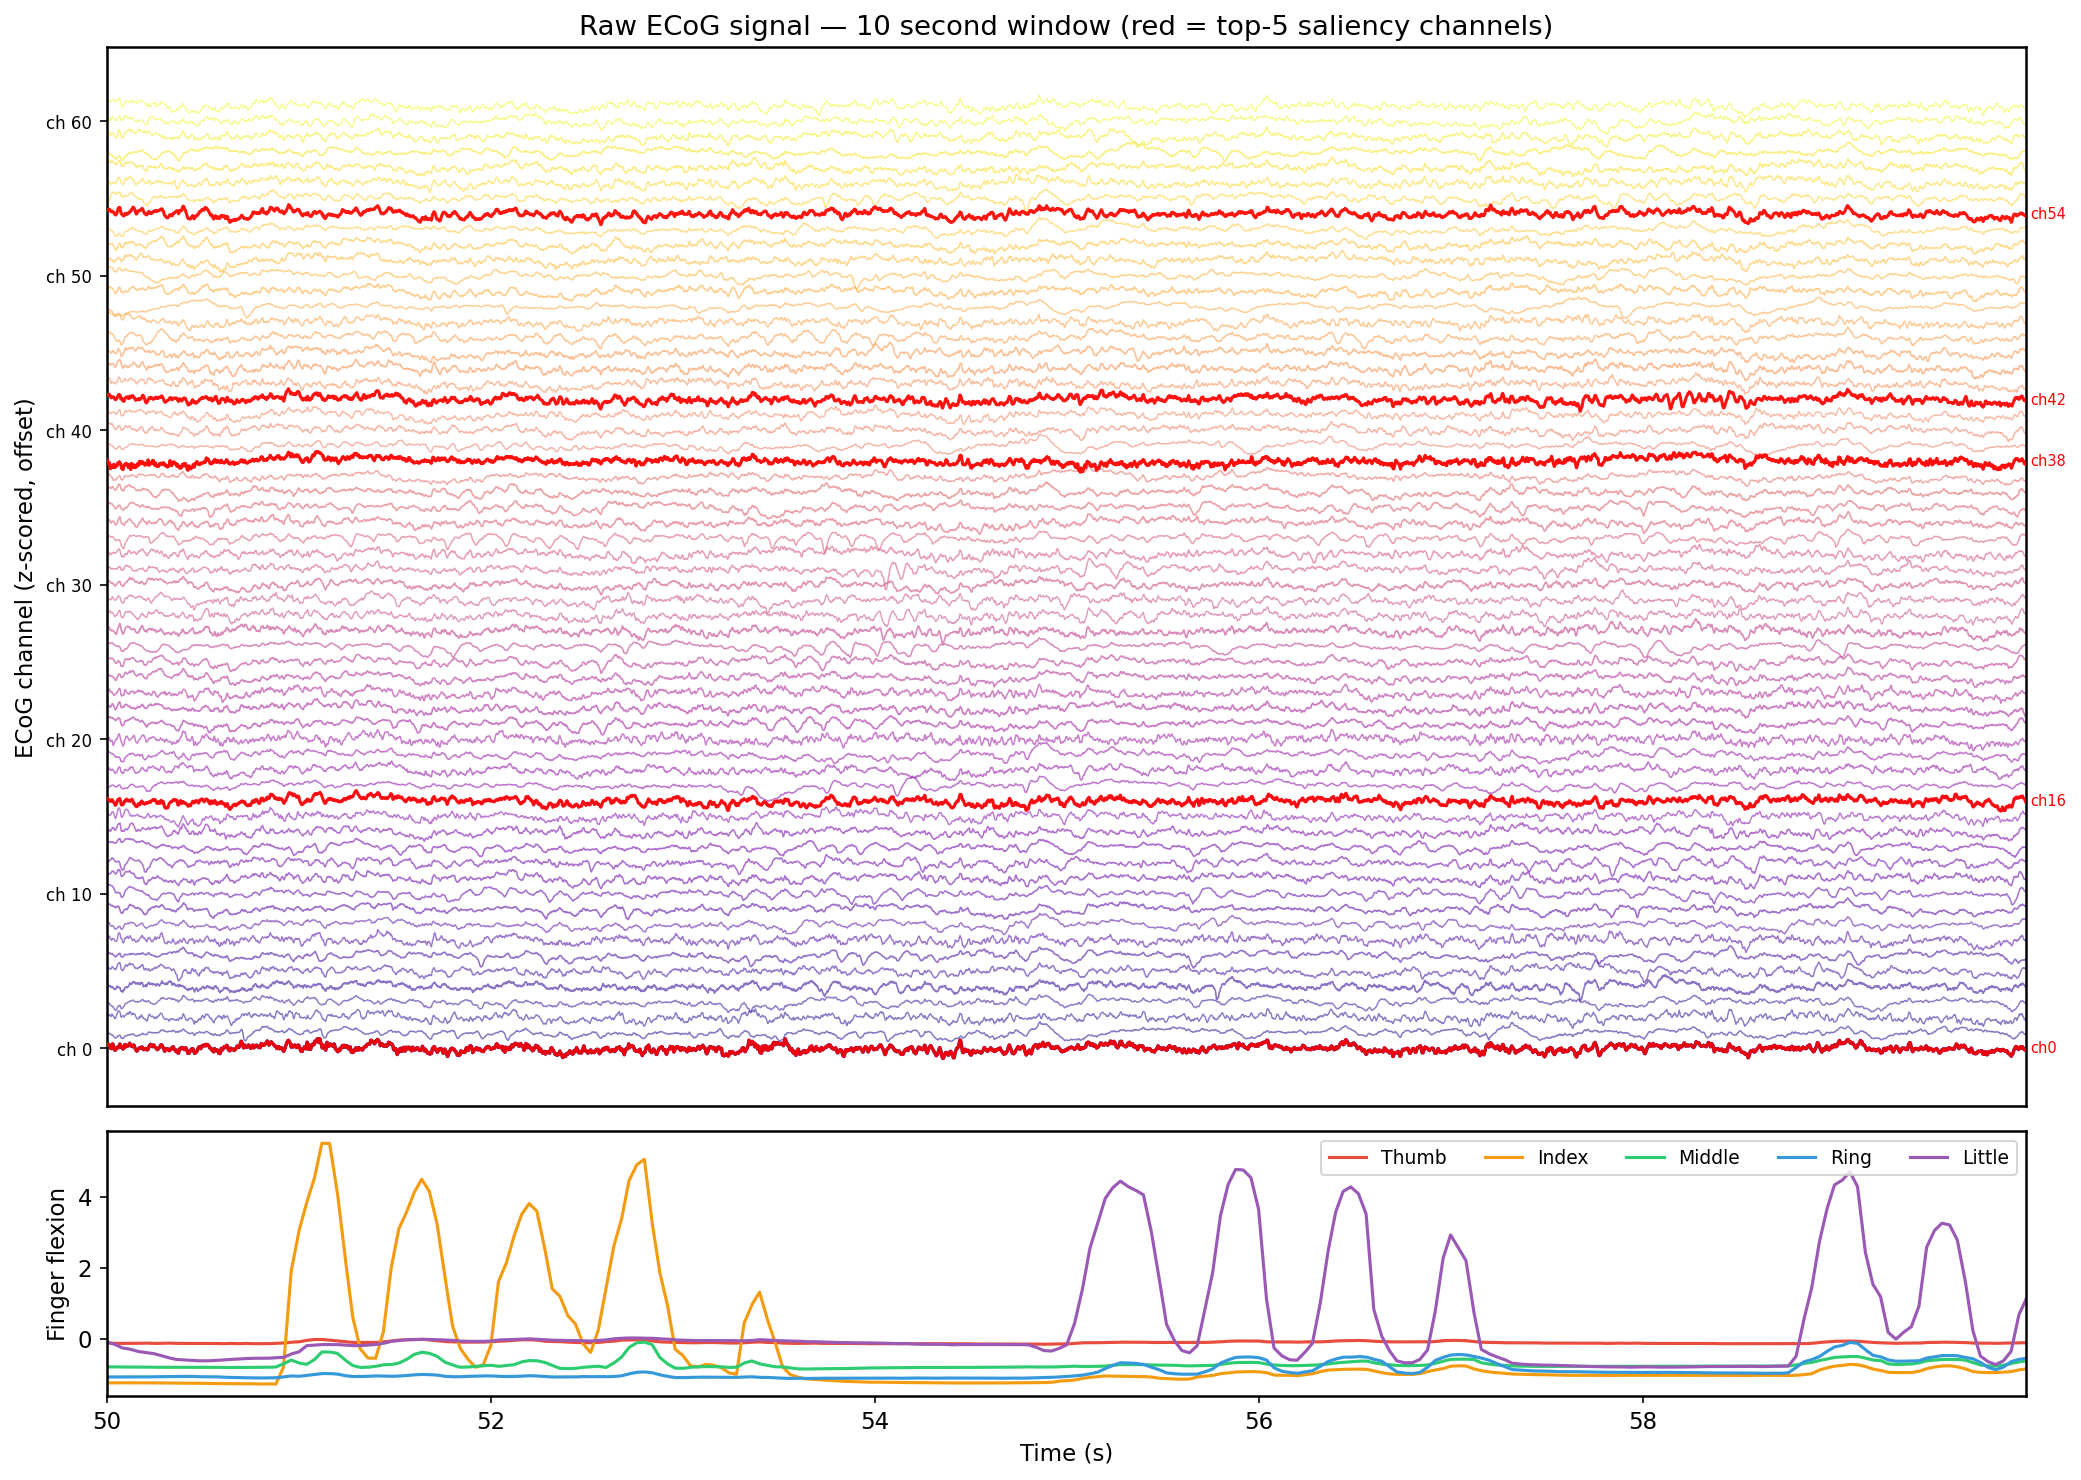

Saved fig6_raw_ecog_fingers


In [ ]:
# ── FIGURE 6: Raw ECoG + finger flexion sample window ────────────────────────
T_START = 50000   # 50 seconds in
T_END   = 60000   # 2 second window
t = np.arange(T_START, T_END) / sfreq

fig, (ax_ecog, ax_fing) = plt.subplots(
    2, 1, figsize=(14, 10),
    gridspec_kw={'height_ratios': [4, 1]}
)

# ECoG — plot every channel, z-scored, offset
ecog_win = ecog_train[:, T_START:T_END].astype(np.float64)
ecog_z   = (ecog_win - ecog_win.mean(axis=1, keepdims=True)) / \
            (ecog_win.std(axis=1, keepdims=True) + 1e-8)
spacing  = 5.0
colors_ecog = plt.cm.plasma(np.linspace(0, 1, 62))

for ch in range(62):
    alpha = 0.4 + 0.5 * saliency[ch] / saliency.max()
    lw    = 0.4 + 1.2 * saliency[ch] / saliency.max()
    ax_ecog.plot(t, ecog_z[ch] + ch * spacing,
                 color=colors_ecog[ch], lw=lw, alpha=alpha)

# Highlight top-5 saliency channels
top5 = np.argsort(-saliency)[:5]
for ch in top5:
    ax_ecog.plot(t, ecog_z[ch] + ch * spacing,
                 color='red', lw=1.5, alpha=0.9, zorder=5)
    ax_ecog.text(t[-1] + 0.02, ch * spacing, f'ch{ch}',
                 fontsize=7, color='red', va='center')

ax_ecog.set_ylabel('ECoG channel (z-scored, offset)')
ax_ecog.set_title('Raw ECoG signal — 10 second window (red = top-5 saliency channels)')
ax_ecog.set_yticks(np.arange(0, 62, 10) * spacing)
ax_ecog.set_yticklabels([f'ch {i}' for i in range(0, 62, 10)], fontsize=8)
ax_ecog.set_xlim(t[0], t[-1])
ax_ecog.set_xticks([])

# Fingers
for i in range(5):
    f = fingers_train[i, T_START:T_END]
    ax_fing.plot(t, f, color=FINGER_COLORS[i], lw=1.5, label=FINGER_NAMES[i])

ax_fing.set_xlabel('Time (s)')
ax_fing.set_ylabel('Finger flexion')
ax_fing.legend(loc='upper right', fontsize=9, ncol=5)
ax_fing.set_xlim(t[0], t[-1])

fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6_raw_ecog_fingers.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig6_raw_ecog_fingers.png', bbox_inches='tight')
plt.show()
print("Saved fig6_raw_ecog_fingers")

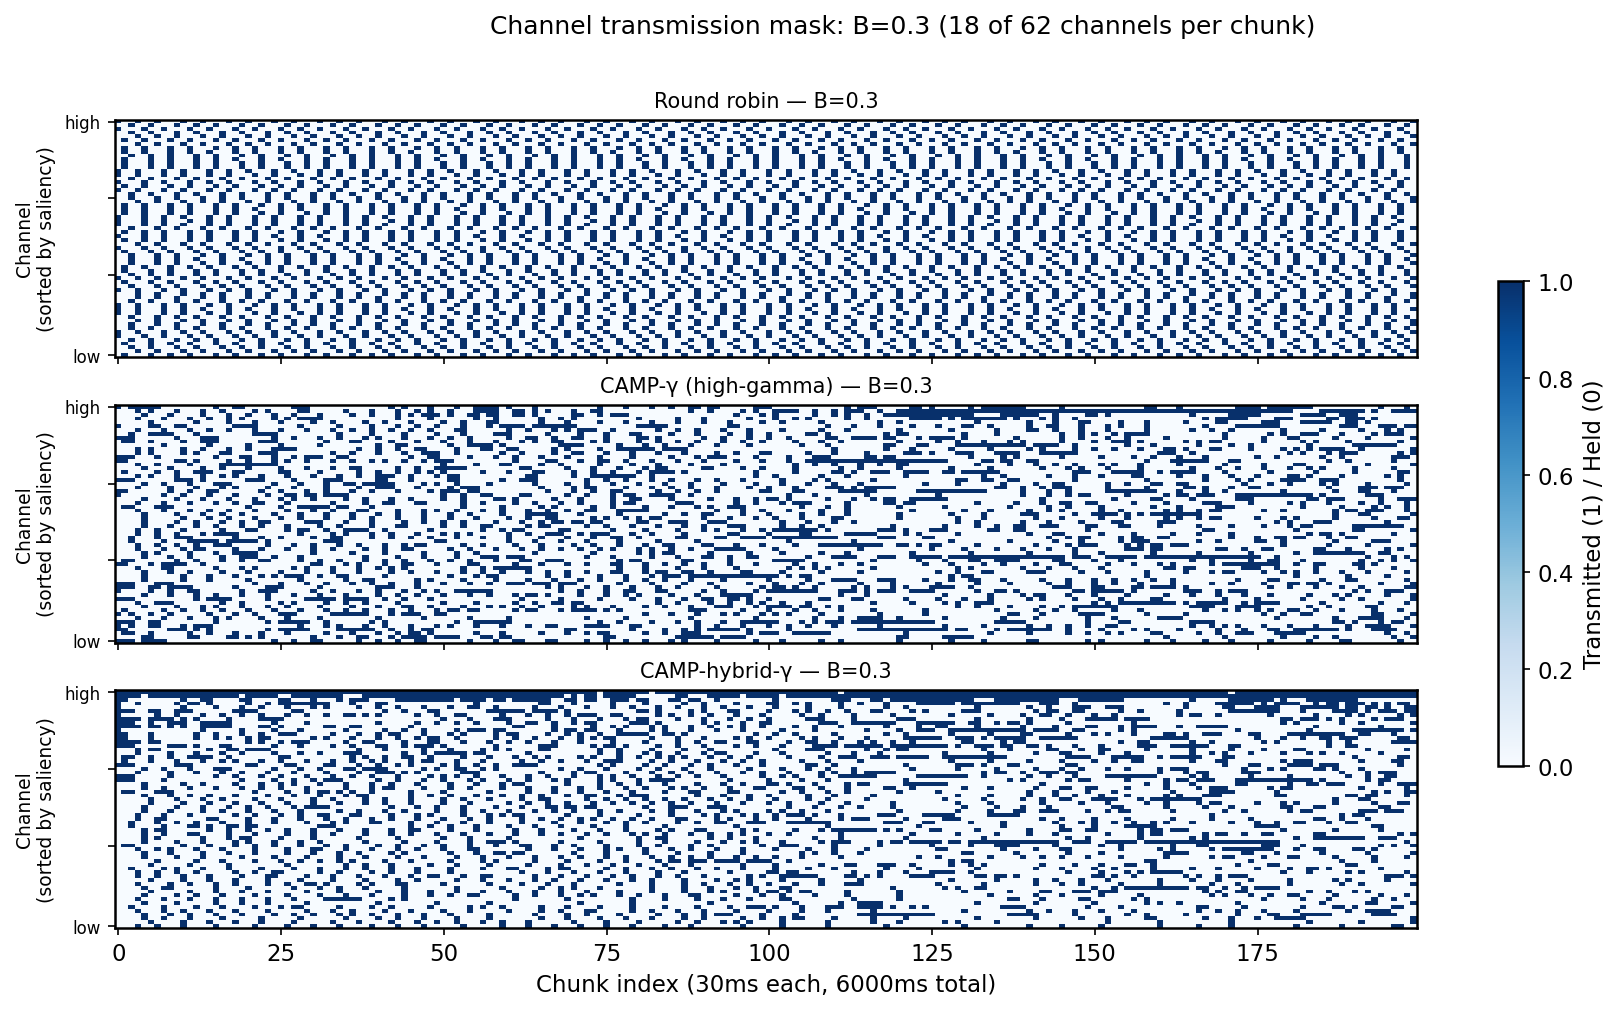

Saved fig7_channel_mask


In [ ]:
# ── FIGURE 7: Channel selection mask — CAMP-γ vs round-robin ─────────────────
from scheduler import ChipSimulator
import numpy as np

N_CHUNKS = 200
CHUNK    = 30
strategies_to_show = ['round_robin', 'camp_gamma', 'camp_hybrid_gamma']
B = 0.3

sal_weights = saliency.copy()

fig, axes = plt.subplots(len(strategies_to_show), 1,
                         figsize=(14, 7), sharex=True)

for ax_i, strat in enumerate(strategies_to_show):
    chip = ChipSimulator(
        n_channels=62, sfreq=sfreq,
        strategy=strat, bandwidth_frac=B, floor_frac=0.1,
        saliency_weights=sal_weights if 'saliency' in strat or 'hybrid' in strat else None,
    )
    mask = np.zeros((62, N_CHUNKS), dtype=np.float32)
    for i in range(N_CHUNKS):
        chunk = ecog_train[:, i*CHUNK:(i+1)*CHUNK]
        _, _, sel = chip.step(chunk, i * CHUNK / sfreq)
        mask[:, i] = sel.astype(np.float32)

    ax = axes[ax_i]
    # Sort channels by saliency for visual clarity
    order = np.argsort(-saliency)
    im = ax.imshow(mask[order], aspect='auto', cmap='Blues',
                   interpolation='nearest', vmin=0, vmax=1)
    ax.set_ylabel('Channel\n(sorted by saliency)', fontsize=9)
    ax.set_title(f'{STRATEGY_STYLE[strat]["label"]} — B={B}', fontsize=10)
    ax.set_yticks([0, 20, 40, 61])
    ax.set_yticklabels(['high', '', '', 'low'], fontsize=8)

axes[-1].set_xlabel(f'Chunk index (30ms each, {N_CHUNKS * 30}ms total)')

plt.colorbar(im, ax=axes, label='Transmitted (1) / Held (0)', shrink=0.6)
fig.suptitle(f'Channel transmission mask: B={B} ({int(B*62)} of 62 channels per chunk)',
             fontsize=12)

fig.savefig(FIG_DIR / 'fig7_channel_mask.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig7_channel_mask.png', bbox_inches='tight')
plt.show()
print("Saved fig7_channel_mask")

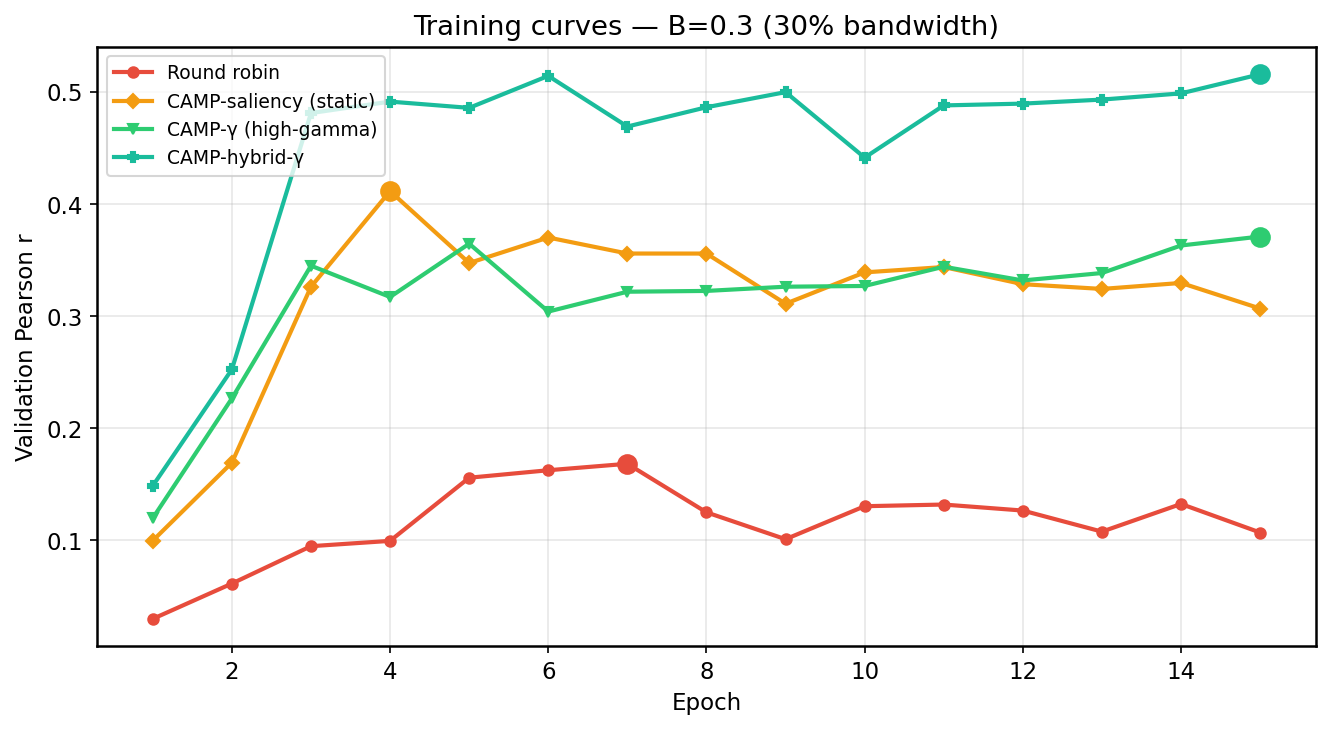

Saved fig8_training_curves


In [ ]:
# ── FIGURE 8: Training curves for key strategies at B=0.3 ────────────────────
strategies_plot = ['round_robin', 'camp_gamma', 'camp_hybrid_gamma', 'camp_saliency']
B_target = 0.3

fig, ax = plt.subplots(figsize=(9, 5))

for r in raw:
    if 'error' in r or 'history' not in r:
        continue
    if r['bandwidth_frac'] != B_target:
        continue
    if r['strategy'] not in strategies_plot:
        continue
    style = STRATEGY_STYLE[r['strategy']]
    epochs = [h['epoch'] for h in r['history']]
    r_vals = [h['r_mean'] for h in r['history']]
    ax.plot(epochs, r_vals, color=style['color'], lw=2,
            marker=style['marker'], markersize=5,
            label=style['label'])
    # Mark best
    best_ep = max(r['history'], key=lambda h: h['r_mean'])
    ax.scatter([best_ep['epoch']], [best_ep['r_mean']],
               color=style['color'], s=80, zorder=5)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Pearson r')
ax.set_title(f'Training curves — B={B_target} (30% bandwidth)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'fig8_training_curves.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig8_training_curves.png', bbox_inches='tight')
plt.show()
print("Saved fig8_training_curves")

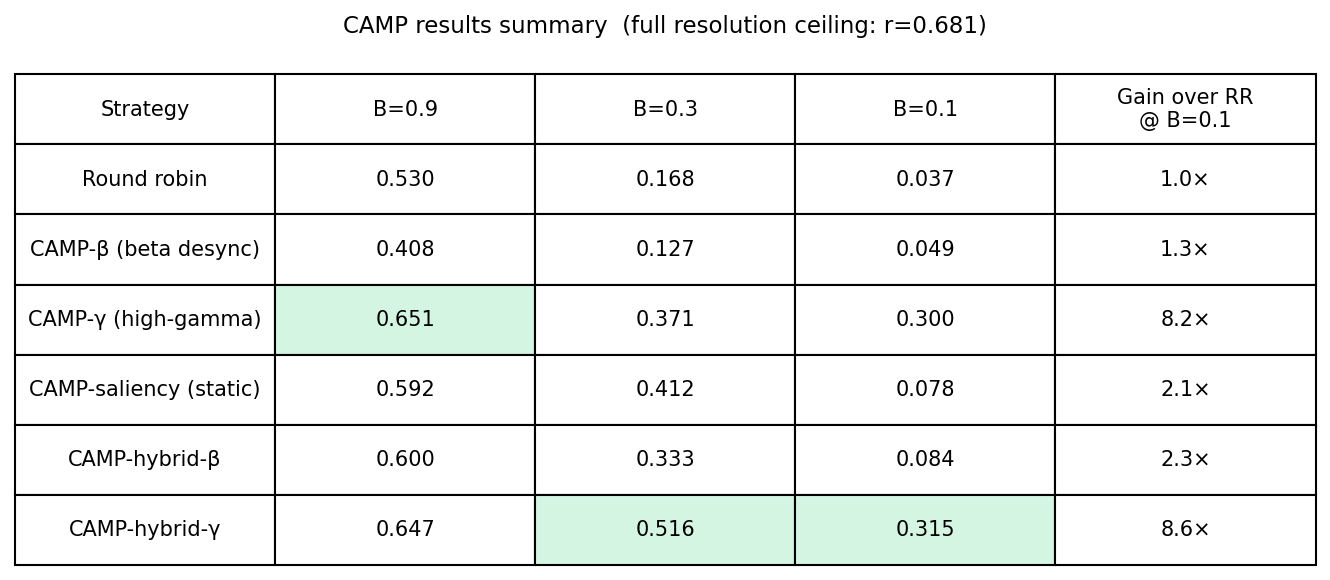

Saved fig9_summary_table


In [ ]:
# ── FIGURE 9: Summary table figure ───────────────────────────────────────────
summary = df[df.strategy.isin(STRATEGY_STYLE.keys())].copy()
summary = summary.pivot(index='strategy', columns='B', values='r_mean')
summary = summary.reindex([s for s in STRATEGY_STYLE if s != 'full'])

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')

full_r_val = df[df.strategy == 'full']['r_mean'].values[0]
col_labels = ['Strategy', 'B=0.9', 'B=0.3', 'B=0.1', 'Gain over RR\n@ B=0.1']
rr_vals = {
    0.9: df[(df.strategy == 'round_robin') & (df.B == 0.9)]['r_mean'].values[0],
    0.3: df[(df.strategy == 'round_robin') & (df.B == 0.3)]['r_mean'].values[0],
    0.1: df[(df.strategy == 'round_robin') & (df.B == 0.1)]['r_mean'].values[0],
}

table_data = []
for strat, row in summary.iterrows():
    r01 = row.get(0.1, np.nan)
    rr01 = rr_vals[0.1]
    gain = f'{r01/rr01:.1f}×' if not np.isnan(r01) and rr01 > 0 else '-'
    table_data.append([
        STRATEGY_STYLE[strat]['label'],
        f"{row.get(0.9, np.nan):.3f}",
        f"{row.get(0.3, np.nan):.3f}",
        f"{r01:.3f}" if not np.isnan(r01) else '-',
        gain,
    ])

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(10)

# Color best value per column green
for col_i in [1, 2, 3]:
    vals = [(i, float(table_data[i][col_i])) for i in range(len(table_data))
            if table_data[i][col_i] != '-']
    best_i = max(vals, key=lambda x: x[1])[0]
    table[best_i + 1, col_i].set_facecolor('#d5f5e3')

ax.set_title(f'CAMP results summary  (full resolution ceiling: r={full_r_val:.3f})',
             fontsize=11, pad=20)

fig.tight_layout()
fig.savefig(FIG_DIR / 'fig9_summary_table.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig9_summary_table.png', bbox_inches='tight')
plt.show()
print("Saved fig9_summary_table")

In [ ]:
# ── List all saved figures ────────────────────────────────────────────────────
print("All figures saved to:", FIG_DIR)
for f in sorted(FIG_DIR.glob('*.png')):
    print(f"  {f.name}")

All figures saved to: /content/drive/MyDrive/CAMP-results/figures
  fig1_main_curve.png
  fig2_relative_gain.png
  fig3_per_finger_heatmap.png
  fig4_saliency.png
  fig5_saliency_concentration.png
  fig6_raw_ecog_fingers.png
  fig7_channel_mask.png
  fig8_training_curves.png
  fig9_summary_table.png
